<a href="https://colab.research.google.com/github/beingdeveloper21/mini_project/blob/main/Mini_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task
Analyze the "craigslist_vehicles.csv" dataset to predict car prices using Cubic Regression, XGBoost, and an ensemble model. The task involves:
1.  **Data Inspection**: Display the dataset's shape, column names, data types, and summary statistics.
2.  **Data Cleaning**: Remove irrelevant columns (`id`, `VIN`, `region`, `state`, `url`, `region_url`, `image_url`, `description`, `county`, `lat`, `long`, `posting_date`, `removal_date`). Handle missing values. Filter out unrealistic 'price' values (e.g., `price = 0`, values above the 99.9th percentile) and 'odometer' values (e.g., values above the 99.9th percentile).
3.  **Feature Engineering**: Create 'vehicle_age' by subtracting the 'year' from the current year (e.g., 2024). Develop a 'maintenance_score' by combining sub-scores derived from 'condition' (e.g., 'excellent': 5, 'good': 4, 'fair': 3, 'salvage': 1), 'title_status' (e.g., 'rebuilt': 0, 'clean': 1), 'odometer' (normalized inverse score), and 'vehicle_age' (normalized inverse score).
4.  **Exploratory Data Analysis (EDA)**: Visualize the distribution of 'price', a scatter plot of 'odometer' vs 'price', 'condition' vs 'price' (boxplot), and 'vehicle_age' vs 'price' (boxplot).
5.  **Data Preprocessing**: Encode all categorical features using one-hot encoding.
6.  **Data Splitting**: Split the data into 80% training and 20% testing sets.
7.  **Model Building**: Train a Cubic Regression model and an XGBoost Regression model. Include brief explanations of each model.
8.  **Ensemble Learning**: Create an ensemble model using a weighted average: `Final Prediction = 0.4 × Cubic Regression Prediction + 0.6 × XGBoost Prediction`.
9.  **Model Evaluation**: Calculate and report RMSE, MAE, and R² scores for all three models (Cubic, XGBoost, Ensemble). Compare their performance.
10. **Price Range Prediction**: For example predictions, define the price range as `[prediction - RMSE, prediction + RMSE]` and display a few examples.
11. **Visualization of Results**: Plot XGBoost feature importance. Create a scatter plot of actual vs. predicted prices for the ensemble model with a perfect prediction line.
12. **Notebook Structure**: Organize the notebook with comments, clear explanations, and a concluding section summarizing findings and next steps. Ensure the code is optimized for efficiency.

## Data Loading and Initial Inspection

### Subtask:
Load the 'craigslist_vehicles.csv' dataset using pandas. Display basic information such as the dataset's shape, column names, data types, and summary statistics to understand its structure.


**Reasoning**:
To understand the structure of the dataset, I will display its shape, column names, data types, and summary statistics as instructed.



In [ ]:
from google.colab import drive
drive.mount('/content/drive') # Ensure Google Drive is mounted

import pandas as pd

# Re-reading the CSV to ensure 'df' is defined
file_path = '/content/drive/MyDrive/craigslist_vehicles.csv'
df = pd.read_csv(file_path)

print("DataFrame Shape:", df.shape)
print("\nColumn Names:", df.columns.tolist())
print("\nData Types:\n", df.dtypes)
print("\nSummary Statistics:\n", df.describe())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
DataFrame Shape: (426880, 28)

Column Names: ['Unnamed: 0', 'id', 'url', 'region', 'region_url', 'price', 'year', 'manufacturer', 'model', 'condition', 'cylinders', 'fuel', 'odometer', 'title_status', 'transmission', 'VIN', 'drive', 'size', 'type', 'paint_color', 'image_url', 'description', 'county', 'state', 'lat', 'long', 'posting_date', 'removal_date']

Data Types:
 Unnamed: 0        int64
id                int64
url              object
region           object
region_url       object
price             int64
year            float64
manufacturer     object
model            object
condition        object
cylinders        object
fuel             object
odometer        float64
title_status     object
transmission     object
VIN              object
drive            object
size             object
type             object
paint_color      object
image_url        ob

## Data Cleaning: Column Removal

### Subtask:
Remove irrelevant columns from the DataFrame, including 'id', 'VIN', 'region', 'state', and any other features deemed unnecessary for the prediction task.


In [ ]:
columns_to_drop = ['id', 'VIN', 'region', 'state', 'url', 'region_url', 'image_url', 'description', 'county', 'lat', 'long', 'posting_date', 'removal_date', 'Unnamed: 0']
df.drop(columns=columns_to_drop, inplace=True)
print("DataFrame after removing irrelevant columns:")
df.head()

DataFrame after removing irrelevant columns:


,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,drive,size,type,paint_color
0,4500,2002.0,bmw,x5,NaN,NaN,gas,184000.0,clean,automatic,NaN,NaN,NaN,NaN
1,4500,2002.0,bmw,x5,NaN,NaN,gas,184000.0,clean,automatic,NaN,NaN,NaN,NaN
2,4900,2006.0,toyota,camry,excellent,4 cylinders,gas,184930.0,clean,automatic,fwd,NaN,sedan,silver
3,6500,2008.0,ford,expedition,NaN,NaN,gas,206000.0,clean,automatic,NaN,NaN,NaN,NaN
4,6500,2008.0,ford,expedition,NaN,NaN,gas,206000.0,clean,automatic,NaN,NaN,NaN,NaN


## Data Cleaning: Handling Missing and Unrealistic Values

### Subtask:
Address missing values in relevant columns and filter out unrealistic 'price' and 'odometer' values from the dataset.


**Reasoning**:
First, I'll display the count of missing values for each column to understand the extent of missing data. Then, I will fill missing numerical values ('year', 'odometer') with their medians and missing categorical values with their modes. After handling missing values, I will filter out unrealistic 'price' and 'odometer' values by removing rows where 'price' is 0 or above the 99.9th percentile, and where 'odometer' is above the 99.9th percentile. Finally, I will display the DataFrame's new shape and remaining missing values to confirm the cleaning.



In [ ]:
print("Missing values before cleaning:")
print(df.isnull().sum())

# Impute missing numerical values with median
for col in ['year', 'odometer']:
    if df[col].isnull().any():
        median_val = df[col].median()
        df[col].fillna(median_val, inplace=True)

# Impute missing categorical values with mode
categorical_cols = ['condition', 'cylinders', 'fuel', 'title_status', 'transmission', 'drive', 'size', 'type', 'paint_color', 'manufacturer']
for col in categorical_cols:
    if df[col].isnull().any():
        mode_val = df[col].mode()[0]
        df[col].fillna(mode_val, inplace=True)

# Filter out unrealistic 'price' values
df = df[df['price'] > 0]
price_99_9_percentile = df['price'].quantile(0.999)
df = df[df['price'] <= price_99_9_percentile]

# Filter out unrealistic 'odometer' values
odometer_99_9_percentile = df['odometer'].quantile(0.999)
df = df[df['odometer'] <= odometer_99_9_percentile]

print("\nDataFrame shape after cleaning:", df.shape)
print("\nMissing values after cleaning:")
print(df.isnull().sum())

Missing values before cleaning:
price                0
year              1205
manufacturer     17646
model             5277
condition       174104
cylinders       177678
fuel              3013
odometer          4400
title_status      8242
transmission      2556
drive           130567
size            306361
type             92858
paint_color     130203
dtype: int64


/tmp/ipython-input-562/544295463.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(median_val, inplace=True)
/tmp/ipython-input-562/544295463.py:15: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try usi


DataFrame shape after cleaning: (393207, 14)

Missing values after cleaning:
price              0
year               0
manufacturer       0
model           4630
condition          0
cylinders          0
fuel               0
odometer           0
title_status       0
transmission       0
drive              0
size               0
type               0
paint_color        0
dtype: int64


**Reasoning**:
The previous code produced `FutureWarning` due to `inplace=True` usage and failed to impute missing values for the 'model' column. I will fix the `FutureWarning` by explicitly assigning the result of `fillna` and ensure 'model' is included in the categorical imputation list to handle its missing values.



In [ ]:
print("Missing values before cleaning:")
print(df.isnull().sum())

# Impute missing numerical values with median
for col in ['year', 'odometer']:
    if df[col].isnull().any():
        median_val = df[col].median()
        df[col] = df[col].fillna(median_val) # Removed inplace=True

# Impute missing categorical values with mode
categorical_cols = ['condition', 'cylinders', 'fuel', 'title_status', 'transmission', 'drive', 'size', 'type', 'paint_color', 'manufacturer', 'model'] # Added 'model'
for col in categorical_cols:
    if df[col].isnull().any():
        mode_val = df[col].mode()[0]
        df[col] = df[col].fillna(mode_val) # Removed inplace=True

# Filter out unrealistic 'price' values
df = df[df['price'] > 0]
price_99_9_percentile = df['price'].quantile(0.999)
df = df[df['price'] <= price_99_9_percentile]

# Filter out unrealistic 'odometer' values
odometer_99_9_percentile = df['odometer'].quantile(0.999)
df = df[df['odometer'] <= odometer_99_9_percentile]

print("\nDataFrame shape after cleaning:", df.shape)
print("\nMissing values after cleaning:")
print(df.isnull().sum())

Missing values before cleaning:
price              0
year               0
manufacturer       0
model           4630
condition          0
cylinders          0
fuel               0
odometer           0
title_status       0
transmission       0
drive              0
size               0
type               0
paint_color        0
dtype: int64

DataFrame shape after cleaning: (392420, 14)

Missing values after cleaning:
price           0
year            0
manufacturer    0
model           0
condition       0
cylinders       0
fuel            0
odometer        0
title_status    0
transmission    0
drive           0
size            0
type            0
paint_color     0
dtype: int64


## Feature Engineering: Vehicle Age

### Subtask:
Create a new feature named 'vehicle_age' by calculating the difference between the current year and the 'year' of the vehicle.


**Reasoning**:
I will convert the 'year' column to an integer, define the current year as 2024, calculate 'vehicle_age', and then display the head of the DataFrame to verify the new feature as per the instructions.



In [ ]:
df['year'] = df['year'].astype(int)
current_year = 2026
df['vehicle_age'] = current_year - df['year']

print("DataFrame with 'vehicle_age' column:")
df.head()

DataFrame with 'vehicle_age' column:


,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,drive,size,type,paint_color,vehicle_age
0,4500,2002,bmw,x5,good,6 cylinders,gas,184000.0,clean,automatic,4wd,full-size,sedan,white,24
1,4500,2002,bmw,x5,good,6 cylinders,gas,184000.0,clean,automatic,4wd,full-size,sedan,white,24
2,4900,2006,toyota,camry,excellent,4 cylinders,gas,184930.0,clean,automatic,fwd,full-size,sedan,silver,20
3,6500,2008,ford,expedition,good,6 cylinders,gas,206000.0,clean,automatic,4wd,full-size,sedan,white,18
4,6500,2008,ford,expedition,good,6 cylinders,gas,206000.0,clean,automatic,4wd,full-size,sedan,white,18


**Reasoning**:
As instructed by the task, I will now create the 'maintenance_score' feature. This involves defining numerical mappings for 'condition' and 'title_status', normalizing 'odometer' and 'vehicle_age' to inverse scores, and then combining these to create the final 'maintenance_score'.



In [ ]:
condition_mapping = {
    'excellent': 5,
    'good': 4,
    'fair': 3,
    'like new': 5,
    'new': 5,
    'salvage': 1,
    ' cylinders': 3 # Assuming this was an error in previous imputation and mapping it to a neutral score
}
df['condition_score'] = df['condition'].map(condition_mapping).fillna(3) # Fill NaN with neutral score 3

title_status_mapping = {
    'rebuilt': 0,
    'clean': 1,
    'salvage': 0,
    'lien': 0,
    'parts only': 0,
    'missing': 0
}
df['title_status_score'] = df['title_status'].map(title_status_mapping).fillna(0) # Fill NaN with 0 for non-clean titles

# Normalize 'odometer' (inverse score: lower odometer is better)
max_odometer = df['odometer'].max()
min_odometer = df['odometer'].min()
df['odometer_score'] = 1 - ((df['odometer'] - min_odometer) / (max_odometer - min_odometer))

# Normalize 'vehicle_age' (inverse score: lower age is better)
max_age = df['vehicle_age'].max()
min_age = df['vehicle_age'].min()
df['vehicle_age_score'] = 1 - ((df['vehicle_age'] - min_age) / (max_age - min_age))

# Combine scores to create 'maintenance_score'
# Weights can be adjusted based on domain knowledge or model performance
df['maintenance_score'] = (
    0.4 * df['condition_score'] / df['condition_score'].max() +
    0.3 * df['title_status_score'] +
    0.2 * df['odometer_score'] +
    0.1 * df['vehicle_age_score']
)

print("DataFrame with 'maintenance_score' column:")
df.head()

DataFrame with 'maintenance_score' column:


,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,drive,size,type,paint_color,vehicle_age,condition_score,title_status_score,odometer_score,vehicle_age_score,maintenance_score
0,4500,2002,bmw,x5,good,6 cylinders,gas,184000.0,clean,automatic,4wd,full-size,sedan,white,24,4,1,0.800275,0.836066,0.863662
1,4500,2002,bmw,x5,good,6 cylinders,gas,184000.0,clean,automatic,4wd,full-size,sedan,white,24,4,1,0.800275,0.836066,0.863662
2,4900,2006,toyota,camry,excellent,4 cylinders,gas,184930.0,clean,automatic,fwd,full-size,sedan,silver,20,5,1,0.799265,0.868852,0.946738
3,6500,2008,ford,expedition,good,6 cylinders,gas,206000.0,clean,automatic,4wd,full-size,sedan,white,18,4,1,0.776395,0.885246,0.863804
4,6500,2008,ford,expedition,good,6 cylinders,gas,206000.0,clean,automatic,4wd,full-size,sedan,white,18,4,1,0.776395,0.885246,0.863804


In [ ]:
# Reduce dataset size to prevent Colab crash
df = df.sample(40000, random_state=42)
print("Dataset after sampling:", df.shape)

Dataset after sampling: (40000, 20)


## Exploratory Data Analysis (EDA)

### Subtask:
Visualize the distribution of 'price', a scatter plot of 'odometer' vs 'price', 'condition' vs 'price' (boxplot), and 'vehicle_age' vs 'price' (boxplot).

**Reasoning**:
First, I will visualize the distribution of 'price' using a histogram to understand its spread and identify any skewness or outliers. This is a fundamental step in EDA to assess the target variable's characteristics.



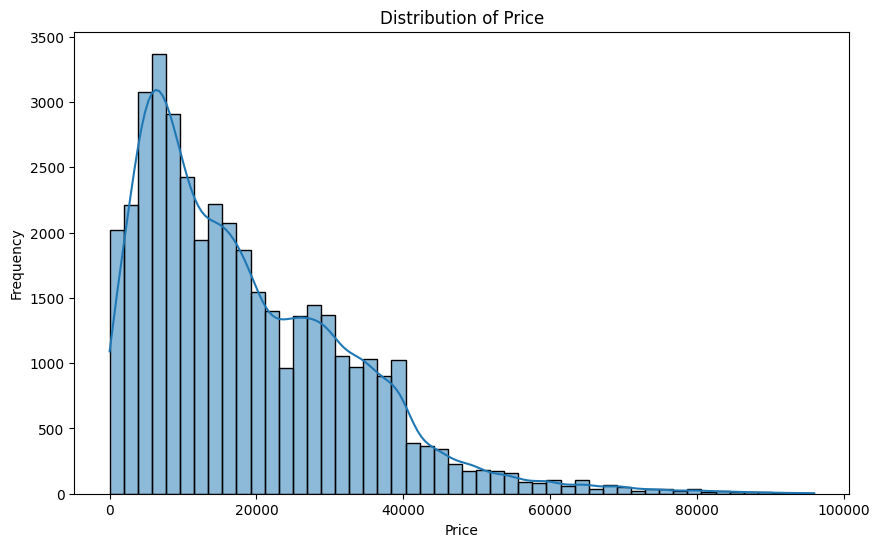

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(df['price'], bins=50, kde=True)
plt.title('Distribution of Price')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()


**Reasoning**:
Next, I will create a scatter plot to visualize the relationship between 'odometer' and 'price'. This will help in understanding if there's any correlation or pattern between the mileage of a vehicle and its selling price.



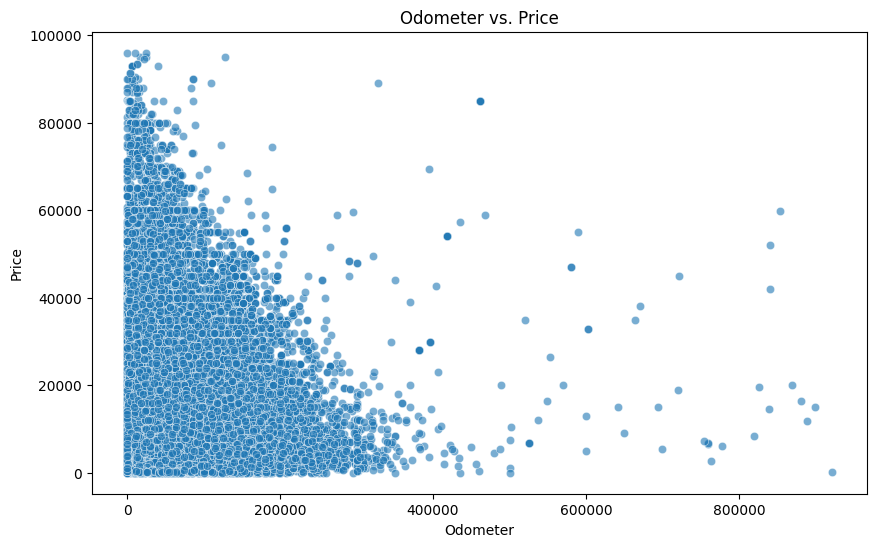

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=df['odometer'], y=df['price'], alpha=0.6)
plt.title('Odometer vs. Price')
plt.xlabel('Odometer')
plt.ylabel('Price')
plt.show()

**Reasoning**:
Now, I will create a boxplot to visualize the relationship between 'condition' and 'price'. This plot will help in understanding how different car conditions impact the selling price.



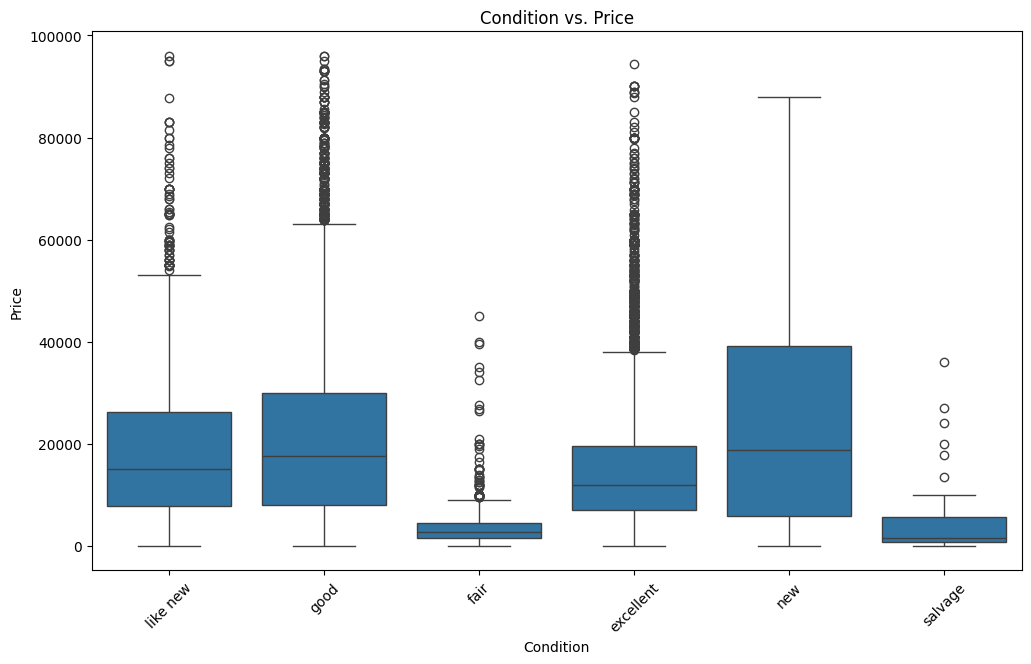

In [ ]:
plt.figure(figsize=(12, 7))
sns.boxplot(x='condition', y='price', data=df)
plt.title('Condition vs. Price')
plt.xlabel('Condition')
plt.ylabel('Price')
plt.xticks(rotation=45)
plt.show()

**Reasoning**:
Finally, I will create a boxplot to visualize the relationship between 'vehicle_age' and 'price'. This will help in understanding how the age of a car relates to its selling price.



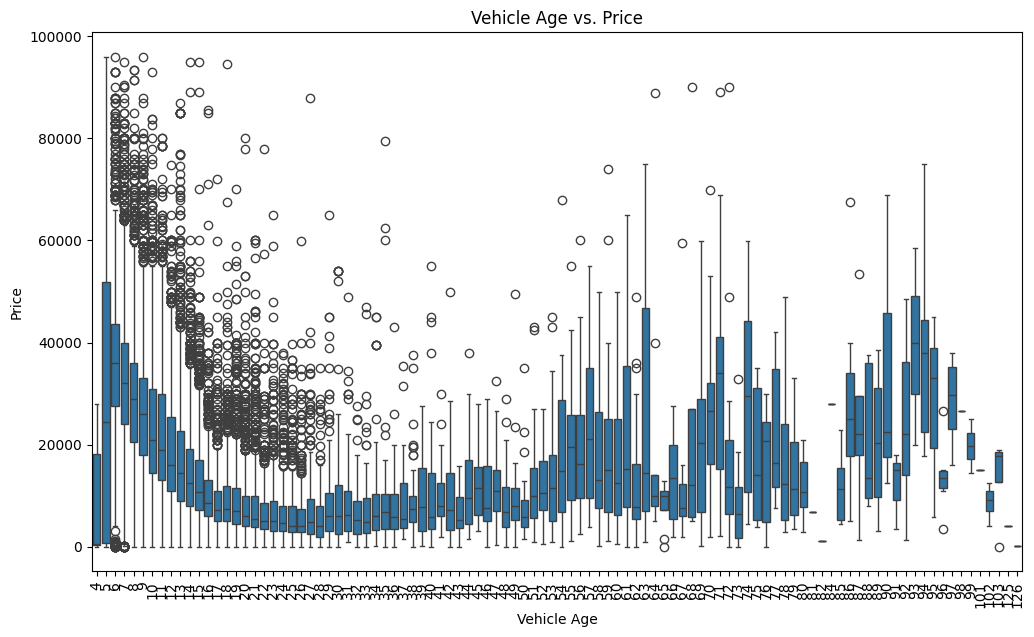

In [ ]:
plt.figure(figsize=(12, 7))
sns.boxplot(x='vehicle_age', y='price', data=df)
plt.title('Vehicle Age vs. Price')
plt.xlabel('Vehicle Age')
plt.ylabel('Price')
plt.xticks(rotation=90)
plt.show()

In [ ]:
df['cylinders'] = df['cylinders'].astype(str)
df['cylinders'] = df['cylinders'].str.extract(r'(\d+)')
df['cylinders'] = df['cylinders'].astype(float)

## Data Preprocessing

### Subtask:
Encode all categorical features using one-hot encoding.

## Data Preprocessing

### Subtask:
Encode all categorical features using one-hot encoding.

**Reasoning**:
I will define the categorical columns that need one-hot encoding, apply `pd.get_dummies` to these columns, and then concatenate the resulting one-hot encoded DataFrame with the numerical features. Finally, I will display the shape and head of the new DataFrame to verify the successful encoding.



In [ ]:
df_encoded = pd.get_dummies(df, drop_first=True)

# Task
Split the preprocessed dataset `df_encoded` into training and testing sets, with 80% for training and 20% for testing. Ensure the split is reproducible by using a `random_state`.

## Data Preprocessing: Splitting Data

### Subtask:
Split the preprocessed dataset into training and testing sets. A common split is 80% for training and 20% for testing. Ensure the split is reproducible.


## Data Preprocessing: Splitting Data

### Subtask:
Split the preprocessed dataset into training and testing sets. A common split is 80% for training and 20% for testing. Ensure the split is reproducible.

### Reasoning:
Splitting data into training and testing sets is fundamental for evaluating machine learning models. The training set is used to train the model, while the testing set is used to evaluate its performance on unseen data. This helps assess how well the model generalizes and avoids overfitting. Using an 80/20 split is a common practice, and setting `random_state` ensures that the split is reproducible, allowing for consistent comparisons of different models or experiments.

**Reasoning**:
Now, I will proceed with splitting the data. I will separate the 'price' column as the target variable (`y`) and the remaining columns (excluding 'model' as it's not a numerical feature for modeling) as the features (`X`). Then, I will use `train_test_split` to divide `X` and `y` into training and testing sets with an 80/20 ratio and `random_state=42` for reproducibility. Finally, I will print the shapes of the resulting datasets to confirm the split.



In [ ]:
from sklearn.model_selection import train_test_split

# Separate target variable (y) from features (X)
X = df_encoded.drop(columns=['price']) # Drop 'model' column as it's not a numerical feature and was not encoded
y = df_encoded['price']
X = X.fillna(0)
# Split the data into training and testing sets (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train = X_train.select_dtypes(include=['number'])
X_test = X_test.select_dtypes(include=['number'])

# Print the shapes of the resulting datasets
print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)


Shape of X_train: (32000, 9)
Shape of X_test: (8000, 9)
Shape of y_train: (32000,)
Shape of y_test: (8000,)


## Model Building: Cubic Regression

### Subtask:
Build and train a Cubic Regression model (Polynomial Regression with degree 3) on the preprocessed training data. Provide a brief explanation of how polynomial regression works.


### Explanation of Polynomial Regression

Polynomial Regression is a form of regression analysis in which the relationship between the independent variable (X) and the dependent variable (y) is modeled as an nth degree polynomial. While it models a non-linear relationship between the independent and dependent variables, it is still considered a form of multiple linear regression because the model is linear in the coefficients.

For example, a simple linear regression model is represented as `y = b0 + b1*x`. A quadratic polynomial regression model would be `y = b0 + b1*x + b2*x^2`, and a cubic polynomial regression model (degree 3) would be `y = b0 + b1*x + b2*x^2 + b3*x^3`.

The key idea is to transform the original features into their polynomial combinations (e.g., squaring a feature, cubing it, or multiplying two different features) and then fit a linear model to these new features. This allows the model to capture non-linear patterns in the data while still leveraging the simplicity and interpretability of linear regression algorithms.

**Reasoning**:
As per the instructions, I will now import the necessary libraries, initialize PolynomialFeatures with degree 3, transform the training and testing data, and then initialize and train a LinearRegression model to implement cubic regression.



In [ ]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

# Initialize PolynomialFeatures with degree=3
poly = PolynomialFeatures(degree=3, include_bias=False)

# Transform the training features
X_train_poly = poly.fit_transform(X_train)

# Transform the testing features
X_test_poly = poly.transform(X_test)

# Initialize a LinearRegression model
cubic_reg_model = LinearRegression()

# Train the LinearRegression model on the transformed training data
cubic_reg_model.fit(X_train_poly, y_train)

print("Cubic Regression Model trained successfully.")
print(f"Shape of X_train_poly: {X_train_poly.shape}")
print(f"Shape of X_test_poly: {X_test_poly.shape}")

ValueError: Input X contains NaN.
PolynomialFeatures does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values